In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
import scipy as sc
import scipy.stats as stats
from scipy.signal import find_peaks
from statsmodels.stats.anova import AnovaRM

sys.path.append('/Users/kjesta/Desktop/LABDATA/Kjersti_100226/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Processed_files/')

from funcs import *
from processing_funcs import *
from analysis_funcs import *
from open_data import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

In [4]:
# For plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle
mplstyle.use(['ggplot', 'fast'])

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

from matplotlib.transforms import ScaledTranslation
from matplotlib.colors import LinearSegmentedColormap
from cmocean import cm as cmo
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

In [3]:
data20 = processed_data_20cm
data30 = processed_data_30cm

In [6]:
freqs20 = list(data20.keys())
volts20 = []

for i in range(len(freqs20)):
    volts20.append(list(data20[freqs20[i]].keys()))

freqs30 = list(data30.keys())
volts30 = []

for i in range(len(freqs30)):
    volts30.append(list(data30[freqs30[i]].keys()))

In [22]:
res = []
for f in freqs20:
    for v in volts20[freqs20.index(f)]:
        for cond in [None, 'p005']:
            for run in ["R1", "R2", "R3"]:
                P0_var = np.var(data20[f][v][cond][run]['P_0'])
                P1_var = np.var(data20[f][v][cond][run]['P_1'])
                P2_var = np.var(data20[f][v][cond][run]['P_2'])
                P3_var = np.var(data20[f][v][cond][run]['P_3'])
                data = {
                    'frequency': f,
                    'voltage': v,
                    'condition': cond,
                    'Run': run,
                    'P0_var': P0_var,
                    'P1_var': P1_var,
                    'P2_var': P2_var,
                    'P3_var': P3_var
                }
                res.append(data)

vars20 = pd.DataFrame(res)

In [21]:
res = []
for f in freqs30:
    for v in volts30[freqs30.index(f)]:
        for cond in [None, 'p005']:
            for run in ["R1", "R2", "R3"]:
                P0_var = np.var(data30[f][v][cond][run]['P_0'])
                P1_var = np.var(data30[f][v][cond][run]['P_1'])
                P2_var = np.var(data30[f][v][cond][run]['P_2'])
                P3_var = np.var(data30[f][v][cond][run]['P_3'])
                data = {
                    'frequency': f,
                    'voltage': v,
                    'condition': cond,
                    'Run': run,
                    'P0_var' : P0_var,
                    'P1_var' : P1_var,
                    'P2_var' : P2_var,
                    'P3_var' : P3_var
                }
                res.append(data)

vars30 = pd.DataFrame(res)

In [23]:
vars20

,frequency,voltage,condition,Run,P0_var,P1_var,P2_var,P3_var
0,1.1,0.1,None,R1,0.000011,0.000010,0.000010,0.000010
1,1.1,0.1,None,R2,0.000011,0.000010,0.000010,0.000010
2,1.1,0.1,None,R3,0.000011,0.000010,0.000010,0.000010
3,1.1,0.1,p005,R1,0.000011,0.000010,0.000009,0.000008
4,1.1,0.1,p005,R2,0.000011,0.000010,0.000009,0.000009
...,...,...,...,...,...,...,...,...
157,1.8,0.3,None,R2,0.000405,0.000392,0.000228,0.000203
158,1.8,0.3,None,R3,0.000412,0.000368,0.000211,0.000239
159,1.8,0.3,p005,R1,0.000247,0.000211,0.000186,0.000224
160,1.8,0.3,p005,R2,0.000237,0.000209,0.000192,0.000381


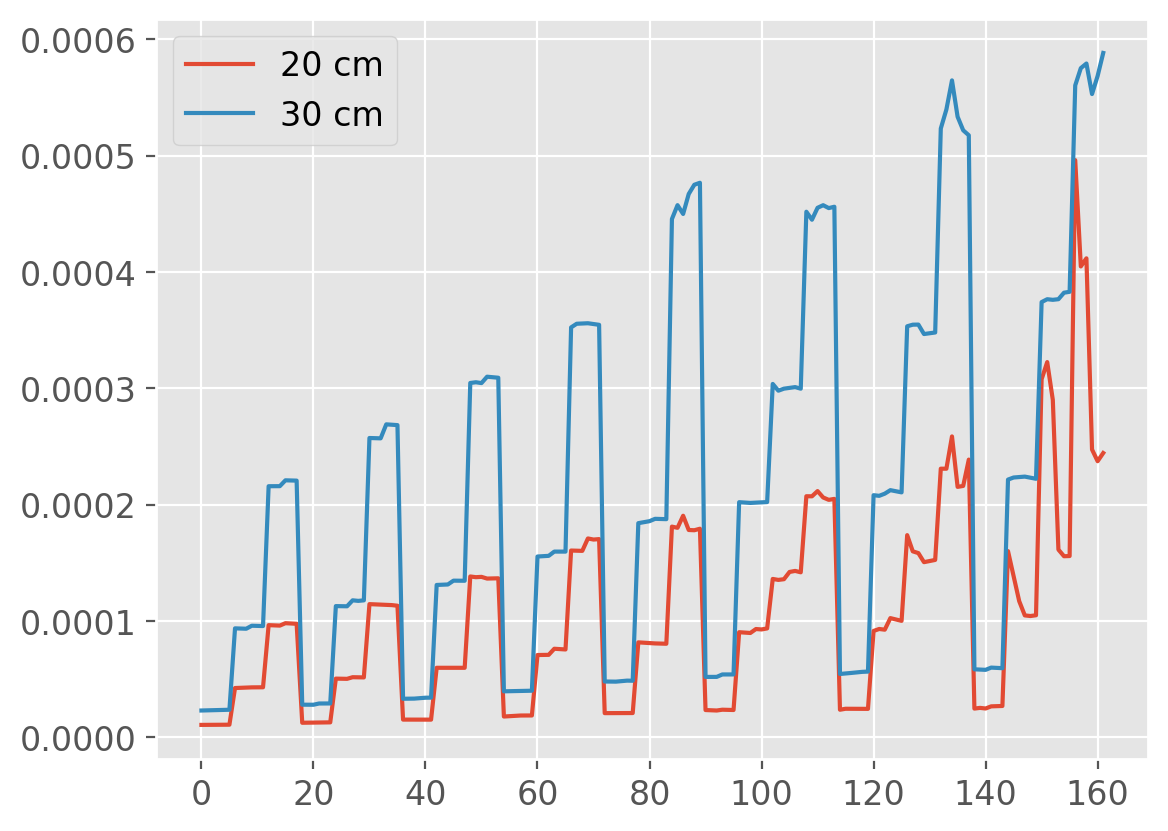

In [28]:
plt.plot(vars20['P0_var'], label='20 cm')
plt.plot(vars30['P0_var'], label='30 cm')
plt.legend()